# Time Series Prediction with PyTorch

In [1]:
import random
import time

import lightning.pytorch as pl
import pandas as pd
from matplotlib import pyplot as plt

from pytorch_forecasting import DeepAR, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import NaNLabelEncoder
from pytorch_forecasting.data.examples import generate_ar_data

In [2]:
total_gpus = 1  # does not work with more than 1!
total_cpus = 8

Generate synthetic time series data.

---

In [3]:
data = generate_ar_data(seasonality=10.0, timesteps=400, n_series=2000, seed=42)
data["date"] = pd.Timestamp("2020-01-01") + pd.to_timedelta(data.time_idx, "D")
data["series"] = data["series"].astype(str)

display(data.head())

,series,time_idx,value,date
0,0,0,-0.000000,2020-01-01
1,0,1,0.138983,2020-01-02
2,0,2,0.284049,2020-01-03
3,0,3,0.454750,2020-01-04
4,0,4,0.619239,2020-01-05


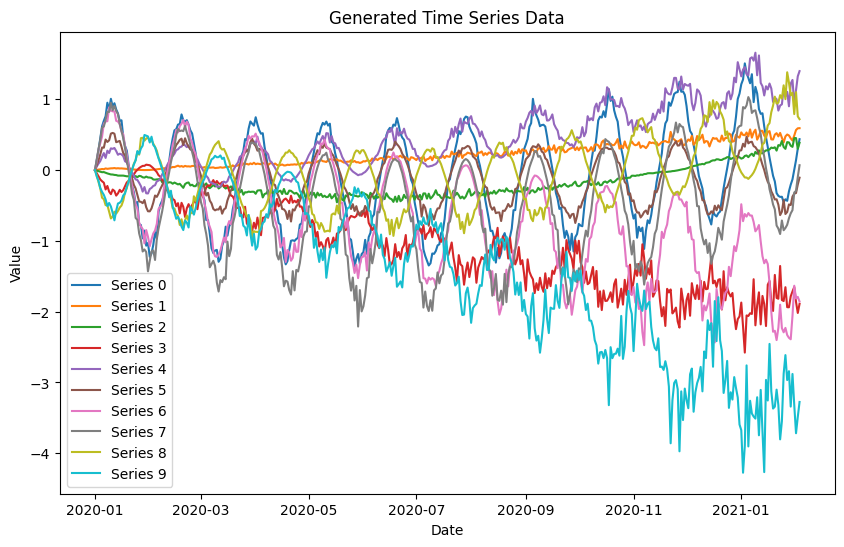

In [4]:
plt.figure(figsize=(10, 6))

for series_id in data.series.unique()[:10]:
    series_data = data[data.series == series_id]
    plt.plot(
        series_data.date,
        series_data.value,
        label=f"Series {series_id}",
    )

plt.legend()
plt.title("Generated Time Series Data")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

Create the training and validation datasets using `TimeSeriesDataSet`. The validation set is generated using `from_dataset()` to ensure the categorical encoders and scalers perfectly match the training set.

---

In [5]:
max_encoder_length = 60
max_prediction_length = 20
training_cutoff = data["time_idx"].max() - max_prediction_length

training = TimeSeriesDataSet(
    data[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="value",
    group_ids=["series"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["series"],
    time_varying_known_reals=["time_idx"],
    time_varying_unknown_reals=["value"],
    categorical_encoders={"series": NaNLabelEncoder().fit(data.series)},
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    data,
    min_prediction_idx=training.index.time.max() + 1,
    stop_randomization=True,
)

In [6]:
batch_size = 256
dataloader_workers = total_cpus - 1

train_dataloader = training.to_dataloader(
    train=True,
    batch_size=batch_size,
    num_workers=dataloader_workers,
    # persistent_workers=dataloader_workers > 0,
)
val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=batch_size,
    num_workers=dataloader_workers,
    # persistent_workers=dataloader_workers > 0,
)

Instantiate a model using the `.from_dataset()` method.

---

In [7]:
pl.seed_everything(42, workers=True)

# model = DeepAR.from_dataset(training)
model = TemporalFusionTransformer.from_dataset(training)
print(f"Number of parameters in network: {model.size() / 1e3:.1f}k")

[rank: 0] Seed set to 42
/net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


Number of parameters in network: 47.6k


Train the model. Early stopping and checkpointing are disabled to ensure a strict 10-epoch performance benchmark.

---

In [8]:
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="gpu",
    devices=total_gpus,
    gradient_clip_val=0.1,
    enable_checkpointing=False,
    logger=False,
    enable_progress_bar=True,
)

start_time = time.time()

trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

print(f"Training Time: {time.time() - start_time:.2f} seconds")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 32.0 K | train | 0    
3  | prescalers                         | ModuleDict                      | 32     | train | 0    
4  | static_variable_selection          | Var

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Training Time: 1326.83 seconds


Plot a sample of results. We sample 5 series prior to generating predictions.

---

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
SLURM auto-requeueing enabled. Setting signal handlers.
/net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/train

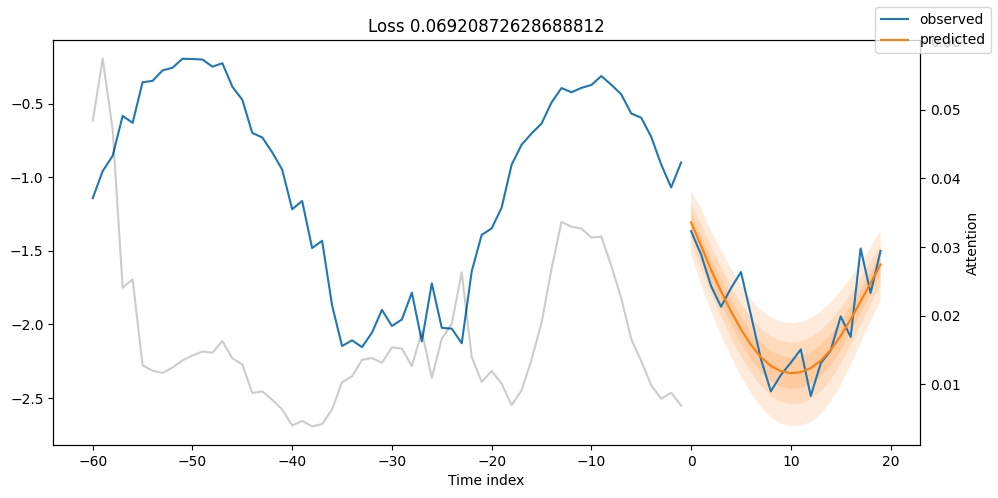

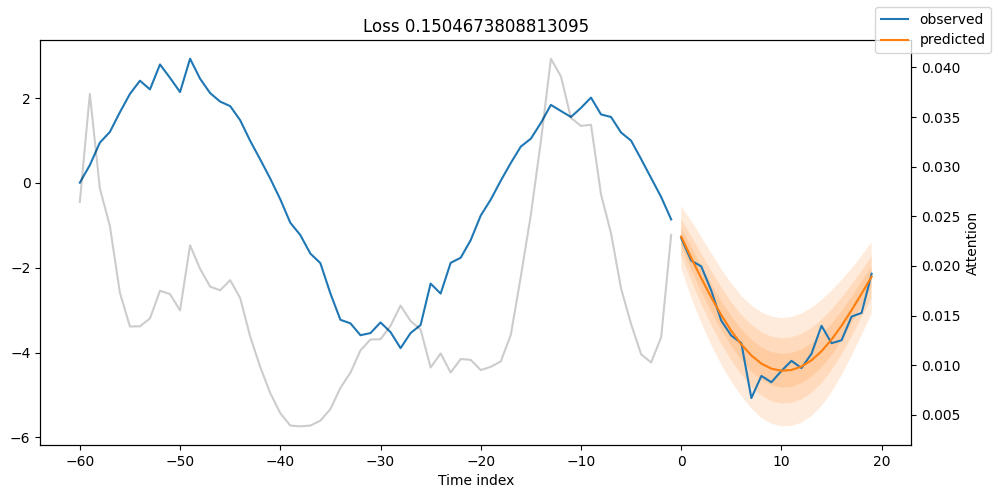

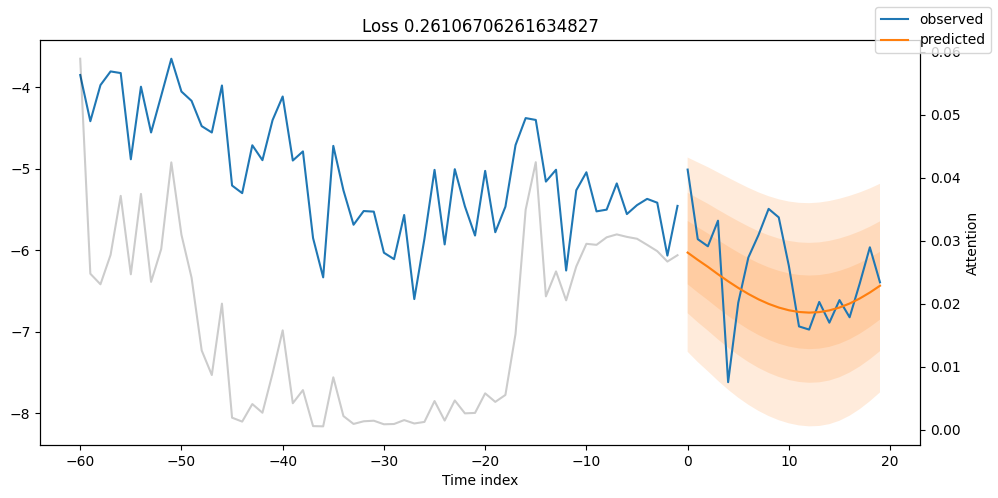

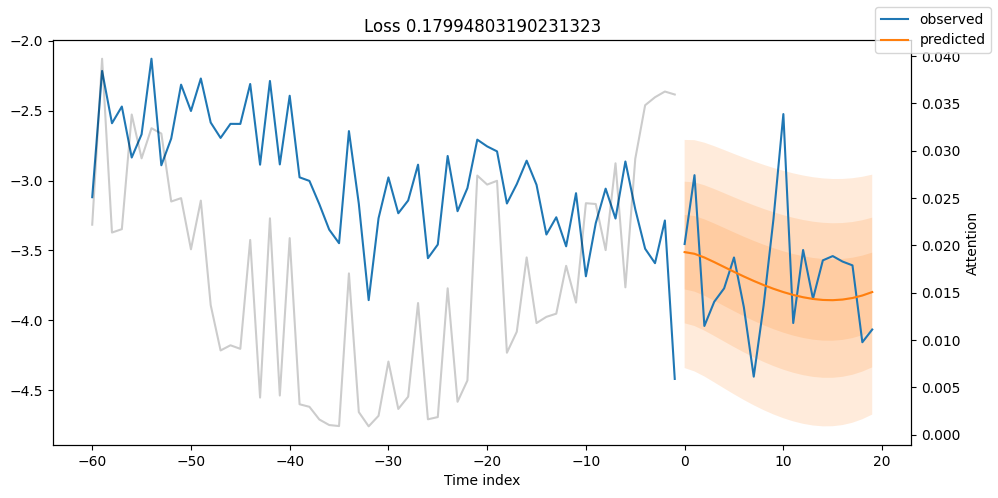

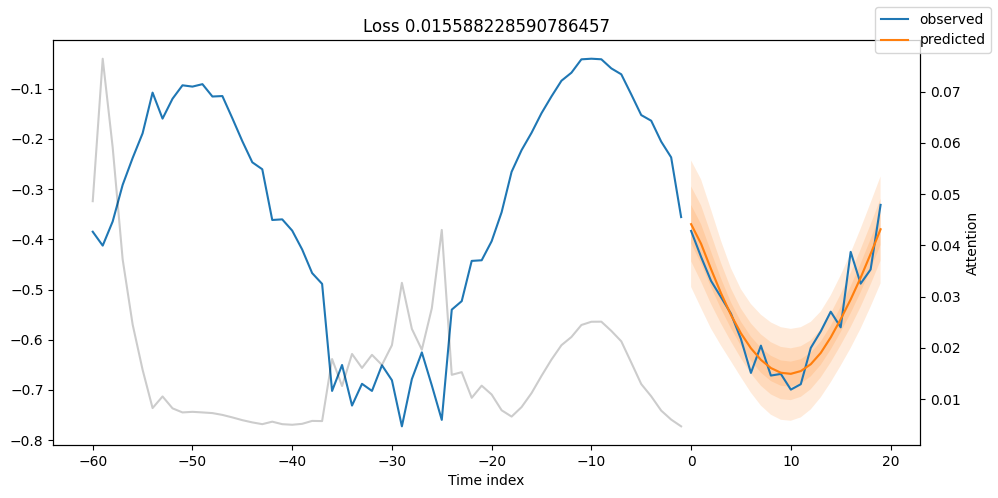

In [9]:
best_model = model

sample_series_ids = random.sample(list(data["series"].unique()), 5)

sample_data = data[data["series"].isin(sample_series_ids)]

raw_predictions = best_model.predict(sample_data, mode="raw", return_x=True)

for idx in range(len(sample_series_ids)):
    fig, ax = plt.subplots(figsize=(10, 5))
    best_model.plot_prediction(
        raw_predictions.x,
        raw_predictions.output,
        idx=idx,
        add_loss_to_title=True,
        ax=ax,
    )
    plt.show()